In [1]:
# Load the MNIST dataset
import numpy as np
mnist_data = np.load('/content/mnist.npz')

# Extract training data and labels
x_train = mnist_data['x_train']
y_train = mnist_data['y_train']
x_test = mnist_data['x_test']
y_test = mnist_data['y_test']

# for i in range(0, 10):
#     print(y_train[i])


x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

x_train01 = []
y_train01 = []
x_test01 = []
y_test01 = []

for i in range(0, len(y_train)):
    if y_train[i] == 0 or y_train[i] == 1:
        x_train01.append(x_train[i])
        y_train01.append(y_train[i])


for i in range(0, len(y_test)):
    if y_test[i] == 0 or y_test[i] == 1:
        x_test01.append(x_test[i])
        y_test01.append(y_test[i])

print(np.array(x_train01).shape)
print(np.array(y_train01).shape)
print(np.array(x_test01).shape)
print(np.array(y_test01).shape)

for i in range(0, len(y_train01)):
    if (y_train01[i] == 0 ):
        y_train01[i] = -1

for i in range(0, len(y_test01)):
    if (y_test01[i] == 0 ):
        y_test01[i] = -1

(12665, 784)
(12665,)
(2115, 784)
(2115,)


In [2]:
import numpy as np

def partition_dataset(x, y, n_val_each_class=1000):
    # Ensure inputs are numpy arrays for safety
    x = np.asarray(x)
    y = np.asarray(y)

    # Find indices for each class
    idx_neg = np.where(y == -1)[0]
    idx_pos = np.where(y == 1)[0]


    # Shuffle indices to ensure randomness
    np.random.shuffle(idx_neg)
    np.random.shuffle(idx_pos)

    # Validation indices
    val_idx_neg = idx_neg[:n_val_each_class]
    val_idx_pos = idx_pos[:n_val_each_class]


    # Training indices
    train_idx_neg = idx_neg[n_val_each_class:]
    train_idx_pos = idx_pos[n_val_each_class:]

    # Combine indices for validation and training
    val_idx = np.concatenate([val_idx_neg, val_idx_pos])
    train_idx = np.concatenate([train_idx_neg, train_idx_pos])

    # Split the dataset into validation and training sets using the indices
    x_val, y_val = x[val_idx], y[val_idx]
    x_train, y_train = x[train_idx], y[train_idx]

    return x_train, y_train, x_val, y_val

# Example usage:
x_train_sub, y_train_sub, x_val, y_val = partition_dataset(x_train01 , y_train01)


In [3]:
import numpy as np

def pca(x, num_components=5):
    # Center the data by subtracting the mean of each feature
    mean = np.mean(x, axis=0)
    x_centered = x - mean

    # Compute the covariance matrix of the centered data
    covariance_matrix = np.cov(x_centered, rowvar=False)

    # Calculate eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Sort the eigenvalues and corresponding eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    # Select the top 'num_components' eigenvectors (principal components)
    principal_components = eigenvectors[:, :num_components]

    # Transform the data using the principal components
    transformed_data = np.dot(x_centered, principal_components)

    return transformed_data #, principal_components, mean

# Using the partitioned training data to compute PCA
x_train_pca = pca(x_train_sub)



# Applying the PCA transformation to the validation set
# x_val_centered = x_val - pca_mean
# x_val_pca = np.dot(x_val_centered, pca_components)
x_val_pca = pca(x_val)
x_test_pca = pca(x_test01)

print(f"Reduced training set shape: {x_train_pca.shape}")
print(f"Reduced validation set shape: {x_val_pca.shape}")
print(f"Reduced test set shape: {x_test_pca.shape}")

Reduced training set shape: (10665, 5)
Reduced validation set shape: (2000, 5)
Reduced test set shape: (2115, 5)


In [4]:
import numpy as np

# Function to calculate SSR
def calculate_ssr(x, y, threshold):
    left_mask = x <= threshold
    right_mask = ~left_mask

    left_y = y[left_mask]
    right_y = y[right_mask]

    if left_y.size > 0:
        left_mean = np.mean(left_y)
    else:
        left_mean = 0

    if right_y.size > 0:
        right_mean = np.mean(right_y)
    else:
        right_mean = 0

    ssr_left = np.sum((left_y - left_mean) ** 2)
    ssr_right = np.sum((right_y - right_mean) ** 2)

    return ssr_left + ssr_right

# Finding the best split
def find_best_split(x, y):
    best_ssr = np.inf
    best_feature = None
    best_threshold = None

    for feature_index in range(x.shape[1]):  # iterate over all features
        feature_values = x[:, feature_index]
        unique_values = np.unique(feature_values)

        if len(unique_values) > 1:
            thresholds = (unique_values[:-1] + unique_values[1:]) / 2

            for threshold in thresholds:
                ssr = calculate_ssr(feature_values, y, threshold)

                if ssr < best_ssr:
                    best_ssr = ssr
                    best_feature = feature_index
                    best_threshold = threshold

    return best_feature, best_threshold

# Training data
x_train_pca = np.array(x_train_pca)
y_train_sub = np.array(y_train_sub)

# Finding the best decision stump
best_feature, best_threshold = find_best_split(x_train_pca, y_train_sub)

print("Best Feature:", best_feature)
print("Best Threshold:", best_threshold)


Best Feature: 0
Best Threshold: 205.8238705735538


In [5]:
def stump_predict(x, feature_index, threshold):
    # Predict 1 if the feature value is greater than the threshold, else -1
    return np.where(x[:, feature_index] > threshold, 1, -1)

# Applying the stump function to get predictions
h1_x = stump_predict(x_train_pca, best_feature, best_threshold)

# Scaling the predictions by 0.01
scaled_h1_x = 0.01 * h1_x

# Calculating the residue
residue = y_train_sub - scaled_h1_x

print("Residue:", residue)


Residue: [-0.99 -0.99 -0.99 ...  0.99  0.99  0.99]


In [6]:
# Step 1: Calculate the new labels as the sign of the previous residue
new_labels = np.sign(residue)

# Step 2: Find the best decision stump for the new labels
best_feature_h2, best_threshold_h2 = find_best_split(x_train_pca, new_labels)

# Step 3: Applying the stump function to get predictions for h2(x)
h2_x = stump_predict(x_train_pca, best_feature_h2, best_threshold_h2)

# Step 4: Scale the predictions by 0.01
scaled_h2_x = 0.01 * h2_x

# Step 5: Calculate the final residue
final_residue = y_train_sub - scaled_h1_x - scaled_h2_x

print("Final Residue:", final_residue)


Final Residue: [-0.98 -0.98 -0.98 ...  0.98  0.98  0.98]


mse =  0.98024
mse =  0.96068
mse =  0.9413199999999997
mse =  0.9221599999999999
mse =  0.9032
mse =  0.8844399999999996
mse =  0.86588
mse =  0.8475199999999997
mse =  0.8293599999999999
mse =  0.8114000000000005
mse =  0.7936399999999999
mse =  0.7760799999999999
mse =  0.7587200000000001
mse =  0.7415599999999999
mse =  0.7246
mse =  0.7078399999999999
mse =  0.6913136000000002
mse =  0.6749531999999998
mse =  0.6588264000000001
mse =  0.6428655999999998
mse =  0.6271384000000001
mse =  0.6115771999999997
mse =  0.5962495999999999
mse =  0.5810942000000002
mse =  0.5661656
mse =  0.5514092
mse =  0.5368795999999999
mse =  0.5225221999999999
mse =  0.5083916000000002
mse =  0.4944332000000001
mse =  0.4807015999999998
mse =  0.4671421999999998
mse =  0.45380960000000004
mse =  0.44064919999999996
mse =  0.42770199999999975
mse =  0.4149672
mse =  0.4024187999999998
mse =  0.3900827999999998
mse =  0.37793319999999975
mse =  0.3659959999999997
mse =  0.3542451999999997
mse =  0.34270

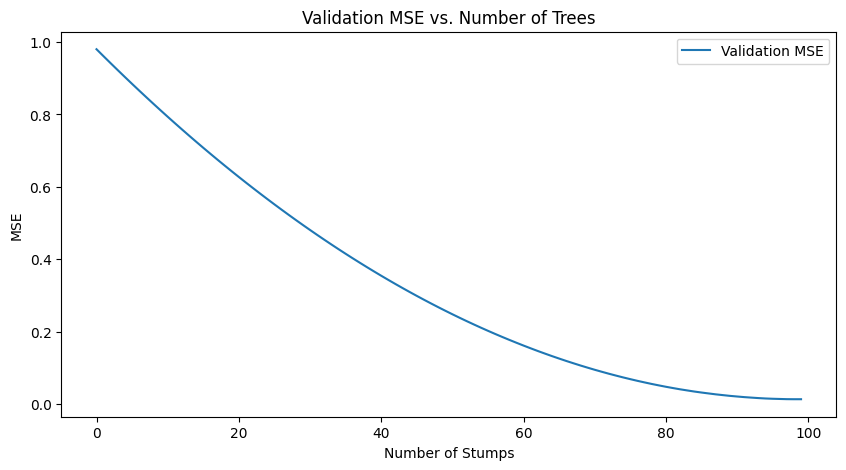

Final MSE after 300 stumps: 0.012881799999999992


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def stump_predict(x, feature_index, threshold):
    # Generates predictions of 1 or -1 based on a threshold on a feature
    return np.where(x[:, feature_index] > threshold, 1, -1)

def update_predictions(current_predictions, new_predictions, learning_rate=0.01):
    # Updates the existing predictions with the new predictions from the latest stump
    return current_predictions + learning_rate * new_predictions

def calculate_mse(y_true, y_pred):
    # Calculates the mean squared error between true labels and predictions
    return np.mean((y_true - y_pred) ** 2)

def calculate_ssr(x, y, threshold):
    # Calculates the sum of squared residuals for a given split (threshold)
    left_mask = x <= threshold
    right_mask = ~left_mask
    left_y = y[left_mask]
    right_y = y[right_mask]
    left_mean = np.mean(left_y) if left_y.size > 0 else 0
    right_mean = np.mean(right_y) if right_y.size > 0 else 0
    ssr_left = np.sum((left_y - left_mean) ** 2)
    ssr_right = np.sum((right_y - right_mean) ** 2)
    return ssr_left + ssr_right

def find_best_split(x, y):
    # Finds the best feature and threshold to split on based on minimizing SSR
    best_ssr = np.inf
    best_feature = None
    best_threshold = None
    for feature_index in range(x.shape[1]):
        feature_values = x[:, feature_index]
        unique_values = np.unique(feature_values)
        if len(unique_values) > 1:
            thresholds = (unique_values[:-1] + unique_values[1:]) / 2
            for threshold in thresholds:
                ssr = calculate_ssr(feature_values, y, threshold)
                if ssr < best_ssr:
                    best_ssr = ssr
                    best_feature = feature_index
                    best_threshold = threshold
    return best_feature, best_threshold

# Main boosting loop
y_train_pred = np.zeros(len(y_train_sub))
y_val_pred = np.zeros(len(y_val))
mse_val = []

for i in range(300):
    residuals = y_train_sub - y_train_pred
    best_feature, best_threshold = find_best_split(x_train_pca, residuals)
    train_predictions = stump_predict(x_train_pca, best_feature, best_threshold)
    val_predictions = stump_predict(x_val_pca, best_feature, best_threshold)

    y_train_pred = update_predictions(y_train_pred, train_predictions)
    y_val_pred = update_predictions(y_val_pred, val_predictions)

    mse = calculate_mse(y_val, y_val_pred)
    mse_val.append(mse)
    print("mse = ", mse)

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(mse_val, label='Validation MSE')
plt.xlabel('Number of Stumps')
plt.ylabel('MSE')
plt.title('Validation MSE vs. Number of Trees')
plt.legend()
plt.show()

print("Final MSE after 300 stumps:", mse_val[-1])
